In [ ]:
# 导入相关包
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive
drive.mount('/content/drive')

import os,gc,re,warnings,sys
warnings.filterwarnings("ignore")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# 读取数据
path = '/content/drive/MyDrive/tian_chi_news/'

#####train
trn_click = pd.read_csv(path+'train_click_log.csv')
item_df = pd.read_csv(path+'articles.csv')
item_df = item_df.rename(columns={'article_id': 'click_article_id'})  #重命名，方便后续match
item_emb_df = pd.read_csv(path+'articles_emb.csv')

#####test
tst_click = pd.read_csv(path+'testA_click_log.csv')

In [17]:
# 数据预处理

# 对每个用户的点击时间戳进行排序
trn_click['rank'] = trn_click.groupby(['user_id'])['click_timestamp'].rank(ascending=False).astype(int)
tst_click['rank'] = tst_click.groupby(['user_id'])['click_timestamp'].rank(ascending=False).astype(int)

#计算用户点击文章的次数，并添加新的一列count
trn_click['click_cnts'] = trn_click.groupby(['user_id'])['click_timestamp'].transform('count')
tst_click['click_cnts'] = tst_click.groupby(['user_id'])['click_timestamp'].transform('count')

In [18]:
# 用户点击日志文件_训练集
trn_click = trn_click.merge(item_df, how='left', on=['click_article_id'])
trn_click.head()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
0,199999,160417,1507029570190,4,1,17,1,13,1,11,11,281,1506942089000,173
1,199999,5408,1507029571478,4,1,17,1,13,1,10,11,4,1506994257000,118
2,199999,50823,1507029601478,4,1,17,1,13,1,9,11,99,1507013614000,213
3,199998,157770,1507029532200,4,1,17,1,25,5,40,40,281,1506983935000,201
4,199998,96613,1507029671831,4,1,17,1,25,5,39,40,209,1506938444000,185


In [19]:
#用户点击日志信息
trn_click.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1112623 entries, 0 to 1112622
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   user_id              1112623 non-null  int64
 1   click_article_id     1112623 non-null  int64
 2   click_timestamp      1112623 non-null  int64
 3   click_environment    1112623 non-null  int64
 4   click_deviceGroup    1112623 non-null  int64
 5   click_os             1112623 non-null  int64
 6   click_country        1112623 non-null  int64
 7   click_region         1112623 non-null  int64
 8   click_referrer_type  1112623 non-null  int64
 9   rank                 1112623 non-null  int64
 10  click_cnts           1112623 non-null  int64
 11  category_id          1112623 non-null  int64
 12  created_at_ts        1112623 non-null  int64
 13  words_count          1112623 non-null  int64
dtypes: int64(14)
memory usage: 118.8 MB


In [20]:
trn_click.describe()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
count,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06
mean,1.221198e+05,1.951541e+05,1.507588e+12,3.947786e+00,1.815981e+00,1.301976e+01,1.310776e+00,1.813587e+01,1.910063e+00,7.118518e+00,1.323704e+01,3.056176e+02,1.506598e+12,2.011981e+02
std,5.540349e+04,9.292286e+04,3.363466e+08,3.276715e-01,1.035170e+00,6.967844e+00,1.618264e+00,7.105832e+00,1.220012e+00,1.016095e+01,1.631503e+01,1.155791e+02,8.343066e+09,5.223881e+01
min,0.000000e+00,3.000000e+00,1.507030e+12,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.166573e+12,0.000000e+00
25%,7.934700e+04,1.239090e+05,1.507297e+12,4.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.300000e+01,1.000000e+00,2.000000e+00,4.000000e+00,2.500000e+02,1.507220e+12,1.700000e+02
50%,1.309670e+05,2.038900e+05,1.507596e+12,4.000000e+00,1.000000e+00,1.700000e+01,1.000000e+00,2.100000e+01,2.000000e+00,4.000000e+00,8.000000e+00,3.280000e+02,1.507553e+12,1.970000e+02
75%,1.704010e+05,2.777120e+05,1.507841e+12,4.000000e+00,3.000000e+00,1.700000e+01,1.000000e+00,2.500000e+01,2.000000e+00,8.000000e+00,1.600000e+01,4.100000e+02,1.507756e+12,2.280000e+02
max,1.999990e+05,3.640460e+05,1.510603e+12,4.000000e+00,5.000000e+00,2.000000e+01,1.100000e+01,2.800000e+01,7.000000e+00,2.410000e+02,2.410000e+02,4.600000e+02,1.510666e+12,6.690000e+03


In [21]:
#训练集中的用户数量为20w
trn_click.user_id.nunique()

200000

In [22]:
trn_click.groupby('user_id')['click_article_id'].count().min()  # 训练集里面每个用户至少点击了两篇文章

2

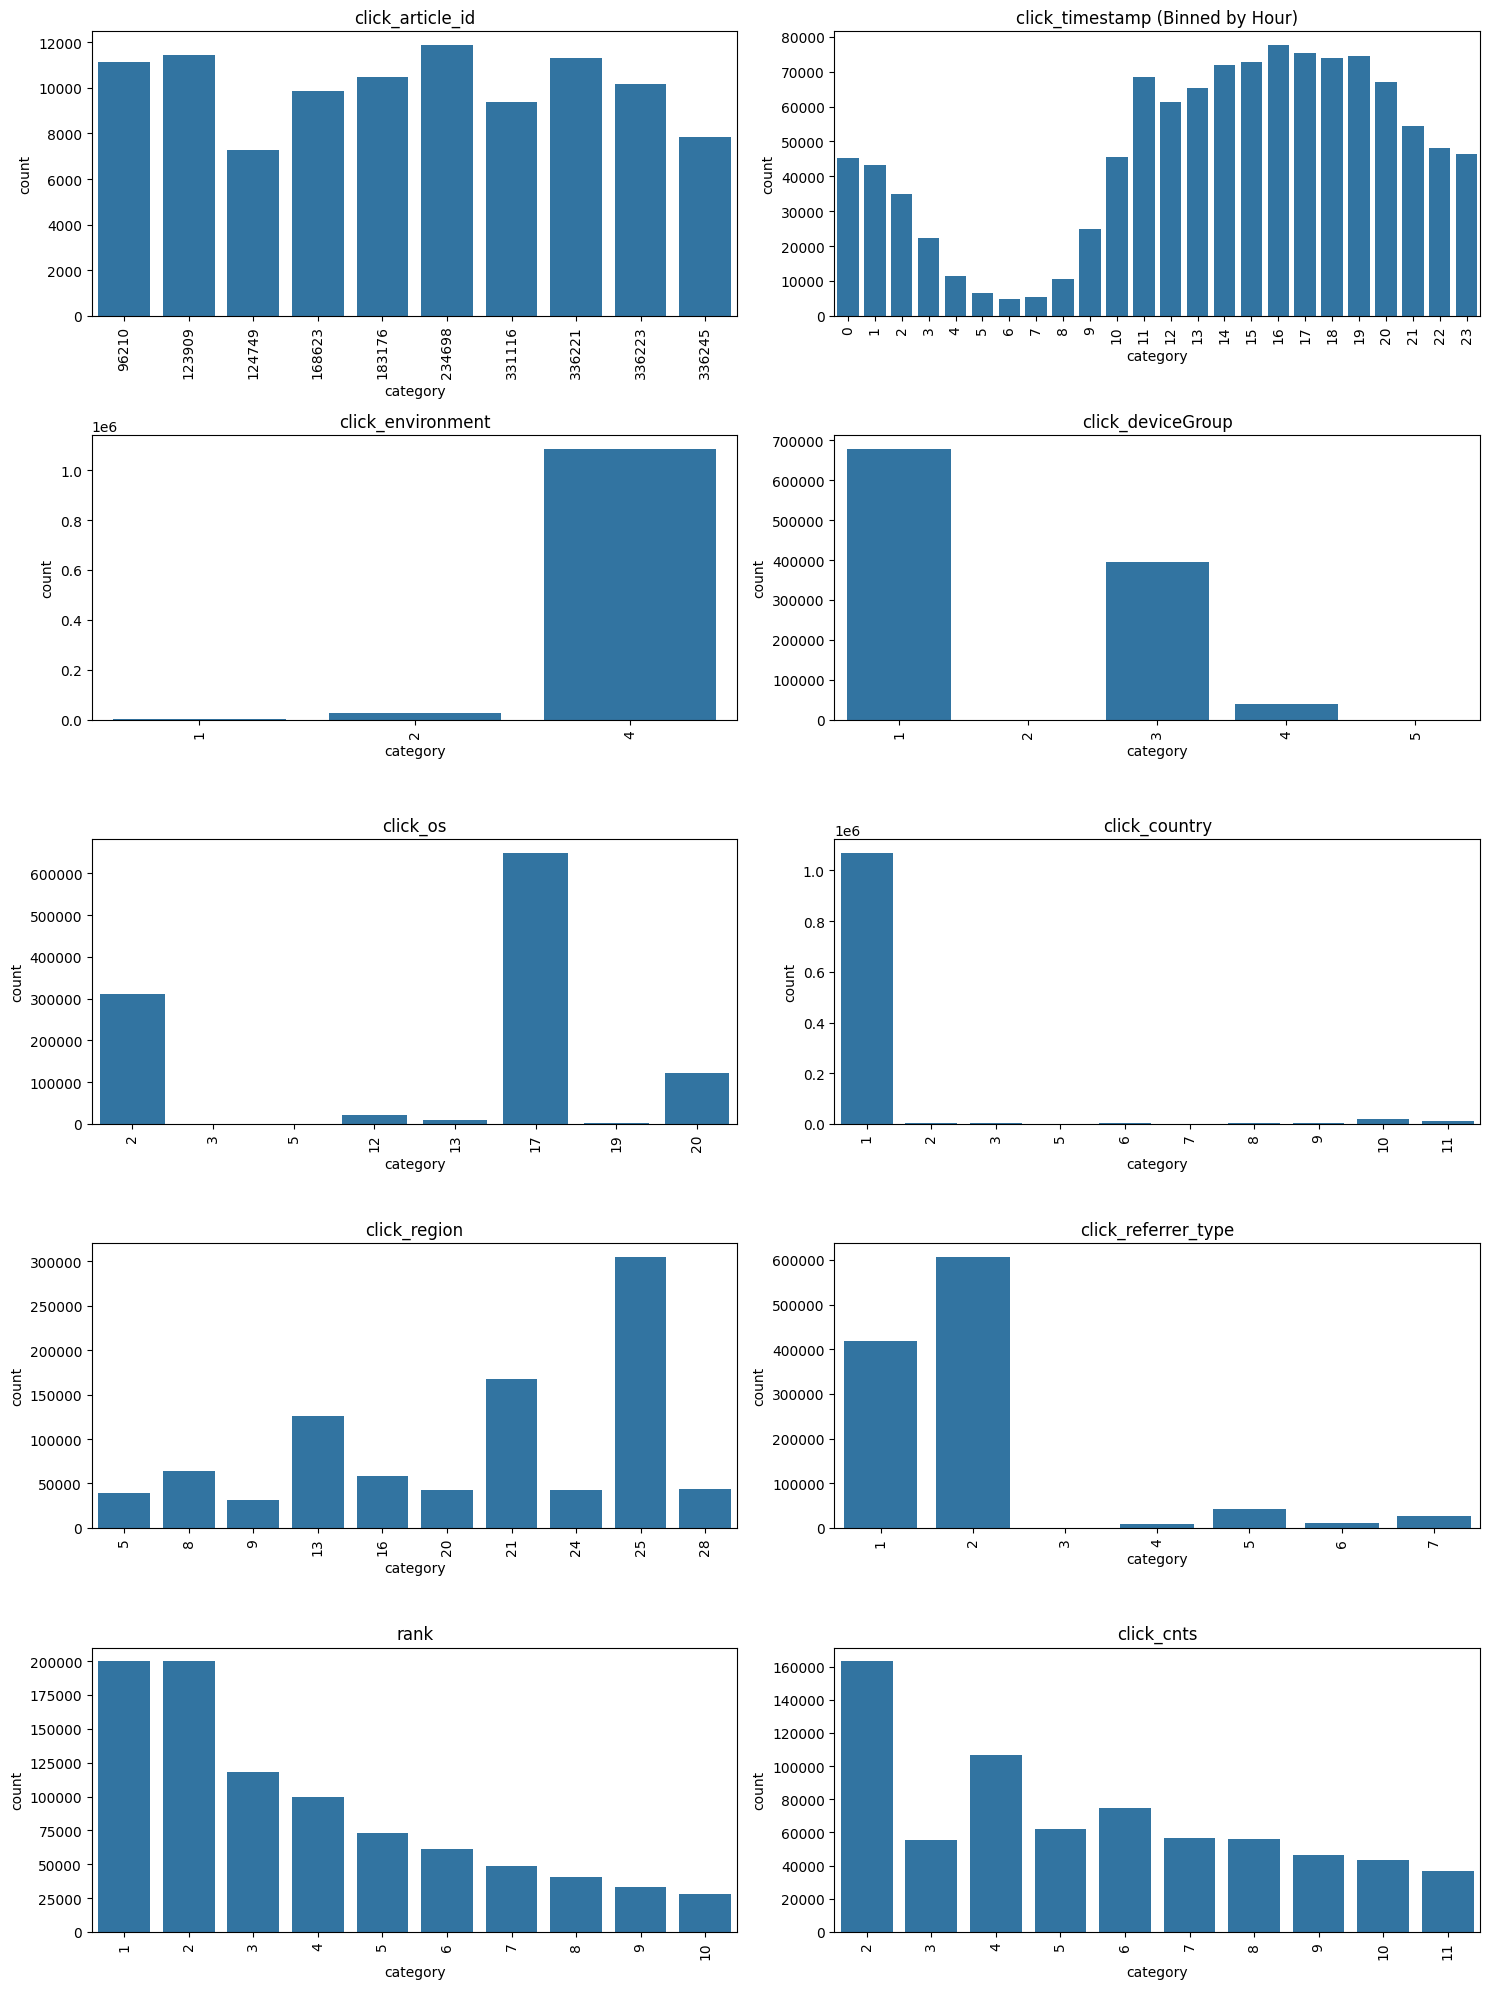

In [26]:
plt.rcdefaults() # 这行代码的作用是：一键恢复 Matplotlib 的默认英文出厂设置！
# 删掉了一个多余的 plt.figure()，直接设置大画布
plt.figure(figsize=(15, 20))
i = 1

columns_to_plot = ['click_article_id', 'click_timestamp', 'click_environment', 'click_deviceGroup', 
                   'click_os', 'click_country', 'click_region', 'click_referrer_type', 'rank', 'click_cnts']

for col in columns_to_plot:
    plot_envs = plt.subplot(5, 2, i)
    i += 1
    
    # 🌟 核心修改点：针对时间戳特征，触发“分桶”逻辑
    if col == 'click_timestamp':
        # 1. 毫秒转为 datetime 格式
        dt_col = pd.to_datetime(trn_click[col], unit='ms')
        # 2. 提取出“小时 (0-23)”作为分桶
        hour_col = dt_col.dt.hour
        # 3. 统计每个小时的点击量，并强制按 0点到23点 排序
        v = hour_col.value_counts().sort_index().reset_index()
        v.columns = ['category', 'count']
        title_suffix = " (Binned by Hour)" # 给标题加个小后缀
        
    else:
        # 其他正常的离散特征，保留原作者的 Top 10 逻辑
        v = trn_click[col].value_counts().reset_index()[:10] 
        v.columns = ['category', 'count']
        title_suffix = ""

    # 开始画图
    fig = sns.barplot(x=v['category'], y=v['count']) 
    for item in fig.get_xticklabels():
        item.set_rotation(90)
        
    plt.title(col + title_suffix) # 动态显示标题

plt.tight_layout()
plt.show()

In [27]:
#新闻文章数据集浏览
pd.concat([item_df.head(), item_df.tail()])

,click_article_id,category_id,created_at_ts,words_count
0,0,0,1513144419000,168
1,1,1,1405341936000,189
2,2,1,1408667706000,250
3,3,1,1408468313000,230
4,4,1,1407071171000,162
364042,364042,460,1434034118000,144
364043,364043,460,1434148472000,463
364044,364044,460,1457974279000,177
364045,364045,460,1515964737000,126
364046,364046,460,1505811330000,479


最早发布时间 2006-09-27 11:14:35
最晚发布时间 2018-03-13 12:12:30


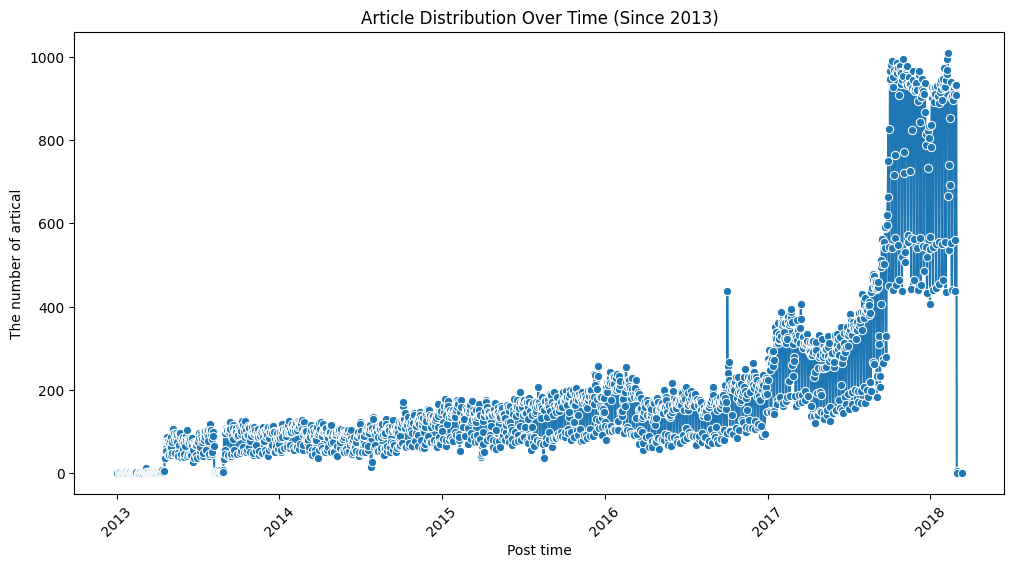

In [29]:
# 新闻文章发布时间分布
news_min_time = item_df['created_at_ts'].min()
news_max_time = item_df['created_at_ts'].max()

print("最早发布时间", pd.to_datetime(news_min_time, unit = 'ms'))
print("最晚发布时间", pd.to_datetime(news_max_time, unit = 'ms'))

# 1️⃣ 过滤掉 2013 年之前的新闻
filtered_item_df = item_df[pd.to_datetime(item_df['created_at_ts'], unit='ms') >= '2013-01-01']

# 2️⃣ 重新按日期统计新闻发布时间
filtered_item_df['creat_date'] = pd.to_datetime(filtered_item_df['created_at_ts'], unit='ms').dt.date
news_per_day = filtered_item_df.groupby('creat_date').size()

# 3️⃣ 绘制新闻发布时间的分布曲线
plt.figure(figsize=(12, 6))
sns.lineplot(x=news_per_day.index, y=news_per_day.values, marker='o')

plt.xlabel("Post time")
plt.ylabel("The number of artical")
plt.title("Article Distribution Over Time (Since 2013)")
plt.xticks(rotation=45)
plt.show()

Min words 0
Max 6690


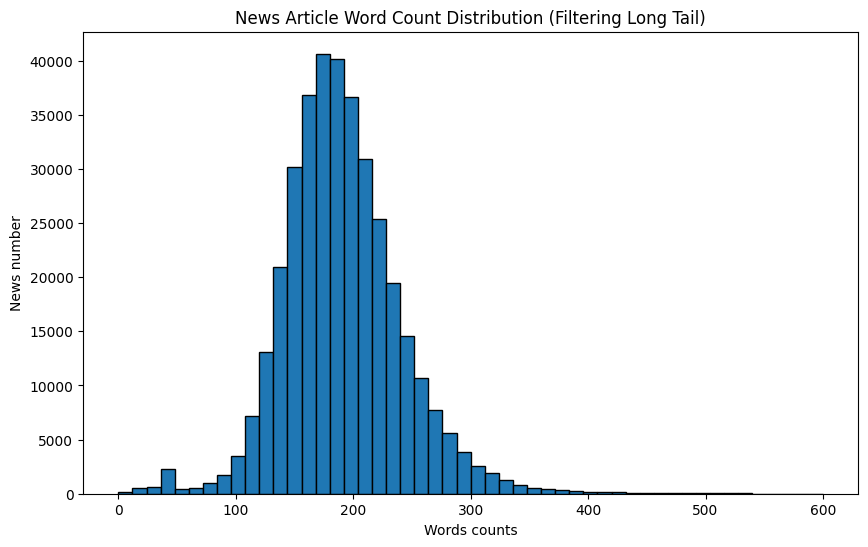

In [30]:
# 新闻文章字数分布
news_min_words_cnt = item_df['words_count'].min()
news_max_words_cnt = item_df['words_count'].max()

print("Min words", news_min_words_cnt)
print("Max", news_max_words_cnt) 

news_words_count = item_df.groupby('words_count').size()
plt.figure(figsize=(10, 6))
# 过滤掉字数 > 1000 的异常数据
filtered_data = item_df[item_df['words_count'] <= 600]

plt.hist(filtered_data['words_count'], bins=50, edgecolor='black')

plt.xlabel("Words counts")
plt.ylabel("News number")
plt.title("News Article Word Count Distribution (Filtering Long Tail)")
plt.show()


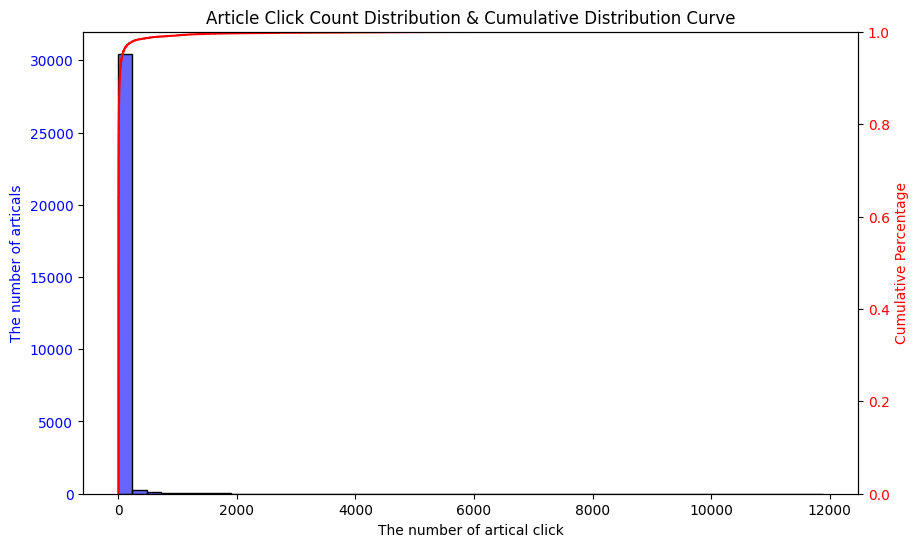

In [31]:

# 统计每篇文章的点击次数
article_click_counts = trn_click['click_article_id'].value_counts()

# 创建图形
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制 直方图（左轴）
sns.histplot(article_click_counts, bins=50, kde=False, ax=ax1, color="blue", alpha=0.6)
ax1.set_xlabel("The number of artical click")
ax1.set_ylabel("The number of articals", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# 创建第二个 y 轴，用于绘制累计分布曲线
ax2 = ax1.twinx()
sns.ecdfplot(article_click_counts, ax=ax2, color="red")  # 叠加累积分布曲线
ax2.set_ylabel("Cumulative Percentage", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Article Click Count Distribution & Cumulative Distribution Curve")
plt.show()


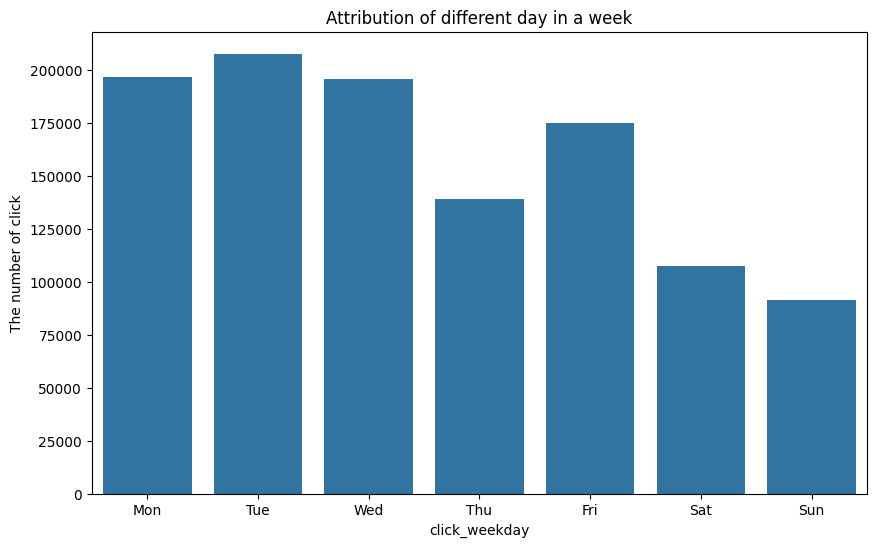

In [35]:
trn_click['click_weekday'] = pd.to_datetime(trn_click['click_timestamp'], unit='ms').dt.weekday

plt.figure(figsize=(10, 6))
sns.countplot(x=trn_click['click_weekday'], order=[0, 1, 2, 3, 4, 5, 6])  # 确保按星期顺序排列
plt.ylabel("The number of click")
plt.title("Attribution of different day in a week")
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])  # 显示中文
plt.show()

In [36]:
tst_click = tst_click.merge(item_df, how='left', on=['click_article_id'])
tst_click.describe()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
count,518010.000000,518010.000000,5.180100e+05,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,5.180100e+05,518010.000000
mean,227342.428169,193803.792550,1.507387e+12,3.947300,1.738285,13.628467,1.348209,18.250250,1.819614,15.521785,30.043586,305.324961,1.506883e+12,210.966331
std,14613.907188,88279.388177,3.706127e+08,0.323916,1.020858,6.625564,1.703524,7.060798,1.082657,33.957702,56.868021,110.411513,5.816668e+09,83.040065
min,200000.000000,137.000000,1.506959e+12,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.265812e+12,0.000000
25%,214926.000000,128551.000000,1.507026e+12,4.000000,1.000000,12.000000,1.000000,13.000000,1.000000,4.000000,10.000000,252.000000,1.506970e+12,176.000000
50%,229109.000000,199197.000000,1.507308e+12,4.000000,1.000000,17.000000,1.000000,21.000000,2.000000,8.000000,19.000000,323.000000,1.507249e+12,199.000000
75%,240182.000000,272143.000000,1.507666e+12,4.000000,3.000000,17.000000,1.000000,25.000000,2.000000,18.000000,35.000000,399.000000,1.507630e+12,232.000000
max,249999.000000,364043.000000,1.508832e+12,4.000000,5.000000,20.000000,11.000000,28.000000,7.000000,938.000000,938.000000,460.000000,1.509949e+12,3082.000000


train最早时间 2017-10-03 11:18:52.200000
train最晚时间 2017-11-13 20:04:14.886000
testA最早时间 2017-10-02 15:44:10.386000
testA最晚时间 2017-10-24 07:56:58.749000


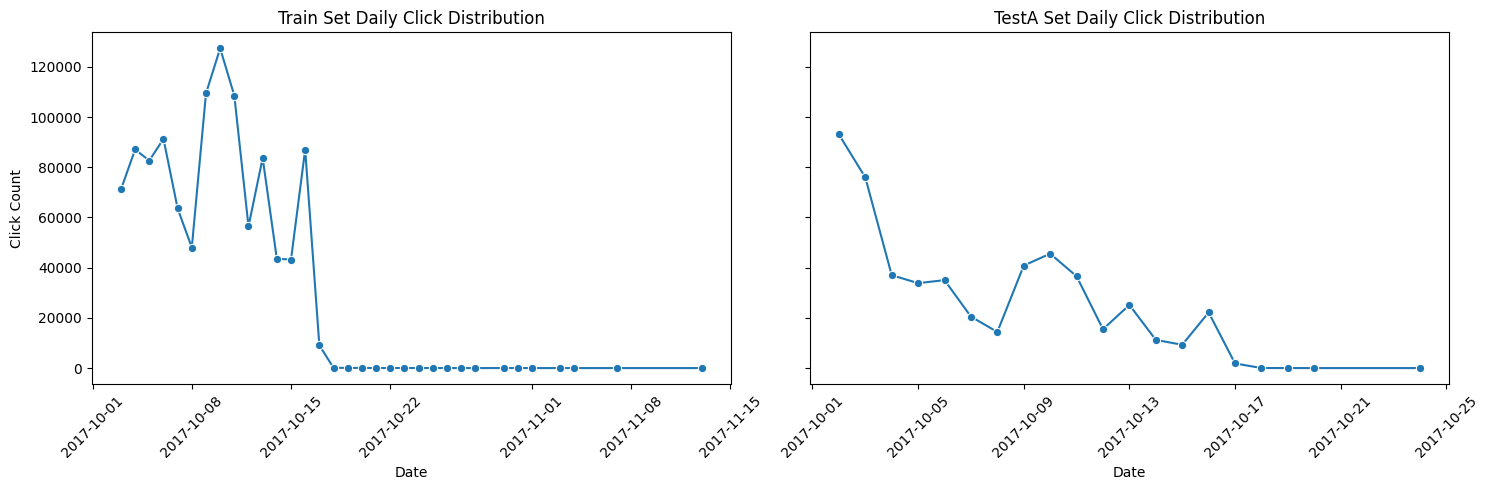

In [37]:
# 文章被点击的时间分布
trn_min_time = trn_click['click_timestamp'].min()
trn_max_time = trn_click['click_timestamp'].max()
tst_min_time = tst_click['click_timestamp'].min()
tst_max_time = tst_click['click_timestamp'].max()

print("train最早时间", pd.to_datetime(trn_min_time, unit = 'ms'))
print("train最晚时间", pd.to_datetime(trn_max_time, unit = 'ms'))
print("testA最早时间", pd.to_datetime(tst_min_time, unit = 'ms'))
print("testA最晚时间", pd.to_datetime(tst_max_time, unit = 'ms'))


# 1️⃣ 确保 click_timestamp 是毫秒时间戳，并转换为日期
trn_click['click_date'] = pd.to_datetime(trn_click['click_timestamp'], unit='ms').dt.date
tst_click['click_date'] = pd.to_datetime(tst_click['click_timestamp'], unit='ms').dt.date

# 2️⃣ 按日期统计点击量
train_clicks_per_day = trn_click.groupby('click_date').size()
testA_clicks_per_day = tst_click.groupby('click_date').size()

# 3️⃣ 绘制双子图：左边是训练集，右边是测试集 A
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# 📌 训练集点击趋势
sns.lineplot(ax=axes[0], x=train_clicks_per_day.index, y=train_clicks_per_day.values, marker='o')
axes[0].set_title("Train Set Daily Click Distribution")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Click Count")
axes[0].tick_params(axis='x', rotation=45)

# 📌 测试集 A 点击趋势
sns.lineplot(ax=axes[1], x=testA_clicks_per_day.index, y=testA_clicks_per_day.values, marker='o')
axes[1].set_title("TestA Set Daily Click Distribution")
axes[1].set_xlabel("Date")
axes[1].tick_params(axis='x', rotation=45)

# 4️⃣ 美化布局
plt.tight_layout()
plt.show()

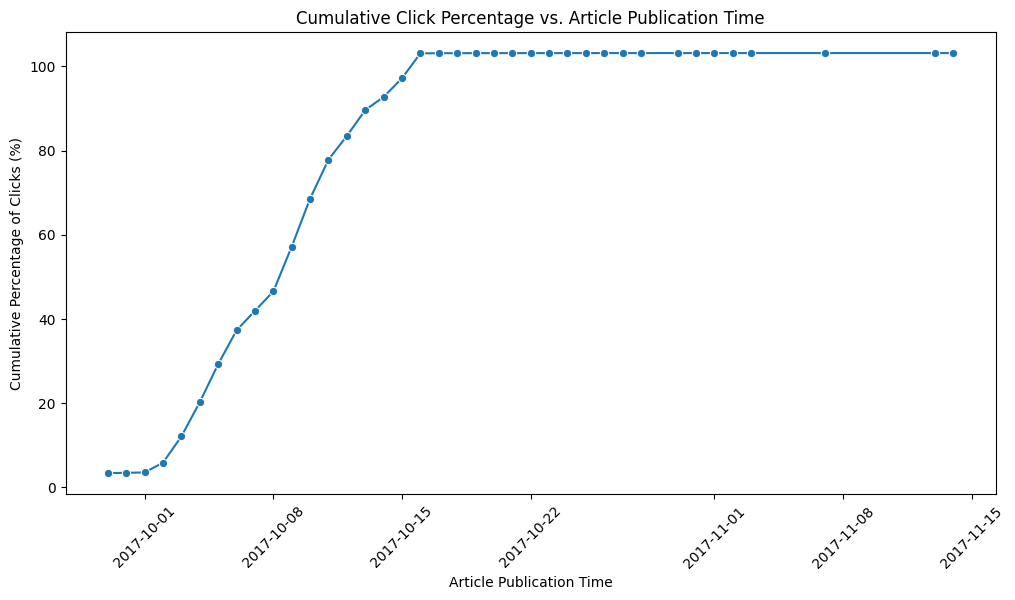

In [40]:
# 1️⃣ 确保 created_at_ts 是毫秒时间戳，并转换为日期
item_df['create_date'] = pd.to_datetime(item_df['created_at_ts'], unit='ms').dt.date

# 2️⃣ 统计每个日期发布的新闻被点击的总次数
news_clicks_per_day = trn_click.merge(item_df[['click_article_id', 'create_date']], 
                                      left_on='click_article_id', right_on='click_article_id')
news_clicks_per_day = news_clicks_per_day.groupby('create_date').size()

# 3️⃣ 过滤掉 2017-09-29 之前的数据
news_clicks_per_day = news_clicks_per_day[news_clicks_per_day.index >= pd.to_datetime('2017-09-29').date()]

# 4️⃣ 计算累积百分比
total_clicks = news_clicks_per_day.sum()
news_clicks_cumsum = news_clicks_per_day.cumsum() / total_clicks * 100

# 5️⃣ 计算 2017-09-29 之前的点击贡献，并加到累积曲线上
pre_2017_clicks = trn_click.merge(item_df[['click_article_id', 'create_date']], 
                                  left_on='click_article_id', right_on='click_article_id')
pre_2017_clicks = pre_2017_clicks[pre_2017_clicks['create_date'] < pd.to_datetime('2017-09-29').date()]
pre_2017_percentage = pre_2017_clicks.shape[0] / total_clicks * 100

news_clicks_cumsum += pre_2017_percentage  # 确保起始值包含之前文章的贡献

# 6️⃣ 绘制新闻发布时间与新闻点击总次数累积百分比的关系
plt.figure(figsize=(12,6))
sns.lineplot(x=news_clicks_cumsum.index, y=news_clicks_cumsum.values, marker='o')

plt.xlabel("Article Publication Time")
plt.ylabel("Cumulative Percentage of Clicks (%)")
plt.title("Cumulative Click Percentage vs. Article Publication Time")
plt.xticks(rotation=45)
plt.show()

In [41]:
#####merge
user_click_merge = pd.concat([trn_click, tst_click], ignore_index=True)
#用户重复点击
user_click_count = user_click_merge.groupby(['user_id', 'click_article_id'])['click_timestamp'].agg({'count'}).reset_index()
user_click_count[:10]

,user_id,click_article_id,count
0,0,30760,1
1,0,157507,1
2,1,63746,1
3,1,289197,1
4,2,36162,1
5,2,168401,1
6,3,36162,1
7,3,50644,1
8,4,39894,1
9,4,42567,1


In [42]:
user_click_count[user_click_count['count']>7]

,user_id,click_article_id,count
311242,86295,74254,10
311243,86295,76268,10
393761,103237,205948,10
393763,103237,235689,10
576902,134850,69463,13


In [43]:
user_click_count['count'].unique()

array([ 1,  2,  4,  3,  6,  5, 10,  7, 13])

In [44]:
#用户点击新闻次数
user_click_count.loc[:,'count'].value_counts() 

,count
count,
1,1605541
2,11621
3,422
4,77
5,26
6,12
10,4
7,3
13,1


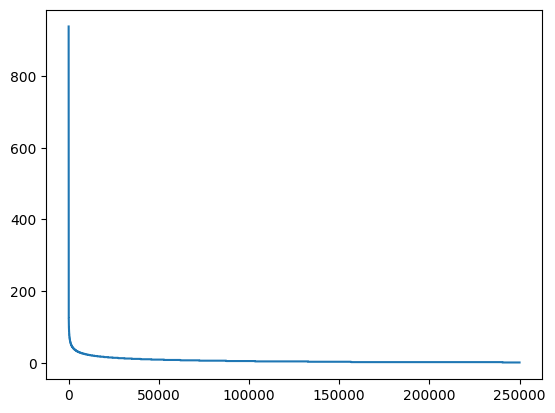

In [45]:
###用户点击新闻数量的分布
user_click_item_count = sorted(user_click_merge.groupby('user_id')['click_article_id'].count(), reverse=True)
plt.plot(user_click_item_count)

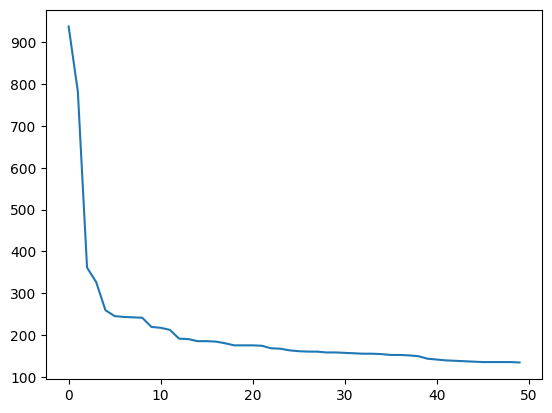

In [ ]:
#点击次数在前50的用户 保证后期截取历史序列的时候的有限性
plt.plot(user_click_item_count[:50])

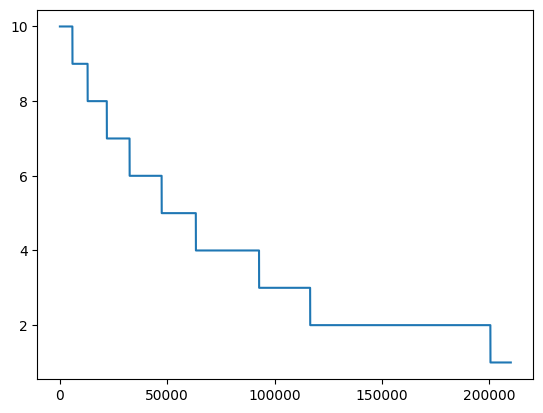

In [48]:
#点击次数排名在[40000:250000]之间
plt.plot(user_click_item_count[40000:250000])

In [49]:
item_click_count = sorted(user_click_merge.groupby('click_article_id')['user_id'].count(), reverse=True)

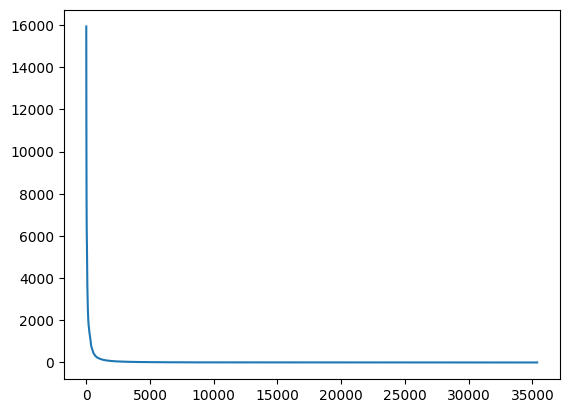

In [50]:
plt.plot(item_click_count)

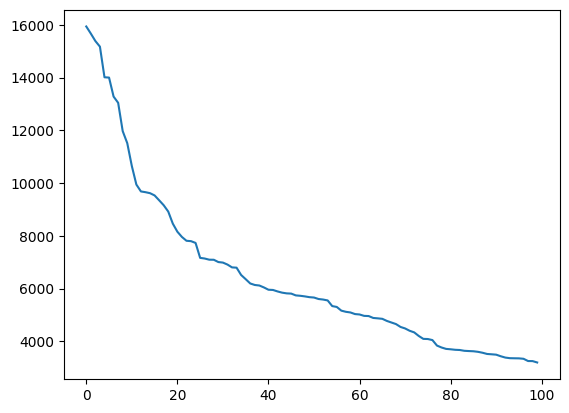

In [51]:
plt.plot(item_click_count[:100])

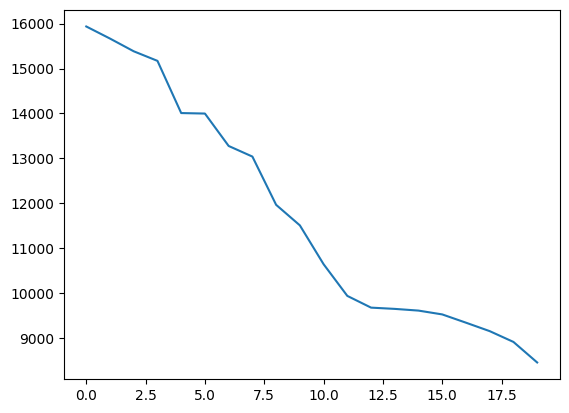

In [52]:
plt.plot(item_click_count[:20])

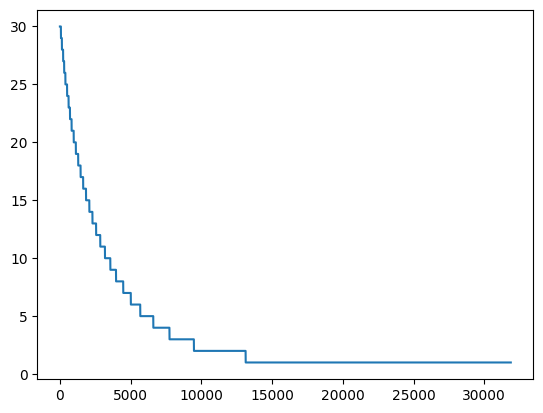

In [53]:
plt.plot(item_click_count[3500:])

In [57]:
tmp = user_click_merge.sort_values('click_timestamp') 
tmp['next_item'] = tmp.groupby(['user_id'])['click_article_id'].transform(lambda x:x.shift(-1))
union_item = tmp.groupby(['click_article_id','next_item'])['click_timestamp'].agg({'count'}).reset_index().sort_values('count', ascending=False)
union_item[['count']].describe()
union_item.head()

,click_article_id,next_item,count
283523,234698,336221.0,2202
404588,336221,95716.0,1762
95454,96210,336245.0,1751
124970,123909,168623.0,1711
12728,20691,96210.0,1568


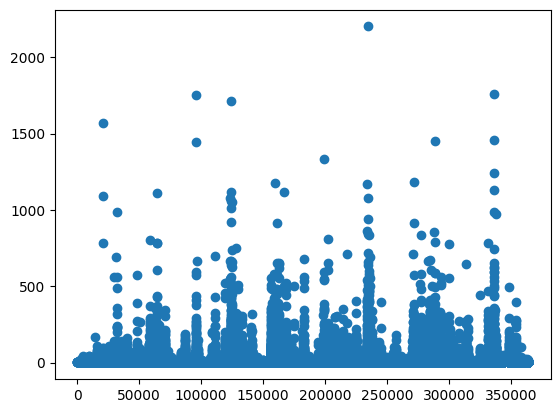

In [56]:
#画个图直观地看一看
x = union_item['click_article_id']
y = union_item['count']
plt.scatter(x, y)

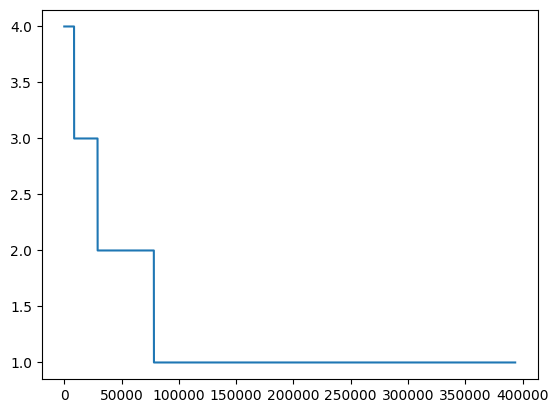

In [58]:
plt.plot(union_item['count'].values[40000:])

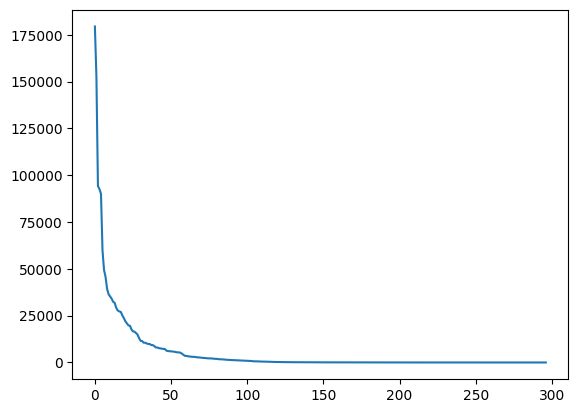

In [59]:
#不同类型的新闻出现的次数
plt.plot(user_click_merge['category_id'].value_counts().values)

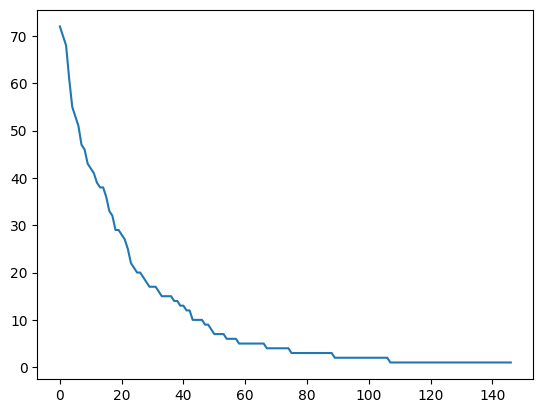

In [60]:
#出现次数比较少的新闻类型, 有些新闻类型，基本上就出现过几次
plt.plot(user_click_merge['category_id'].value_counts().values[150:])

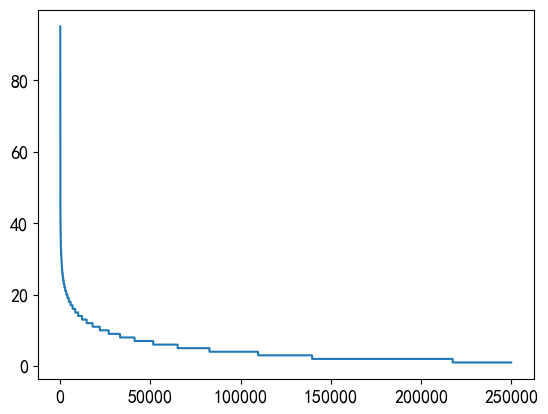

In [ ]:
plt.plot(sorted(user_click_merge.groupby('user_id')['category_id'].nunique(), reverse=True))
# 很关键的数据，会发现发部分用户观看的类目都是小于10的，代表后期确实可以根据用户历史类别来进性新闻推荐，
# 同时对于类目多的“全能型读者” 可以增加注意力机制，减少类目这一因素对其推荐的影响

In [37]:
user_click_merge.groupby('user_id')['category_id'].nunique().reset_index().describe()

,user_id,category_id
count,250000.000000,250000.000000
mean,124999.500000,4.573188
std,72168.927986,4.419800
min,0.000000,1.000000
25%,62499.750000,2.000000
50%,124999.500000,3.000000
75%,187499.250000,6.000000
max,249999.000000,95.000000


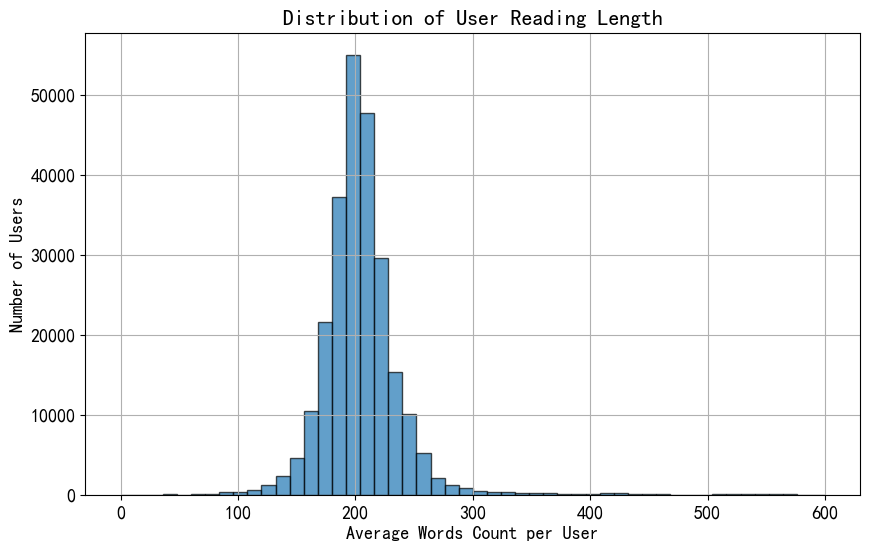

In [38]:
import matplotlib.pyplot as plt

# 计算每个用户的平均阅读字数
user_words_mean = user_click_merge.groupby('user_id')['words_count'].mean()

# 绘制直方图
plt.figure(figsize=(10, 6))
plt.hist(user_words_mean, bins=50, range=(0, 600), edgecolor='black', alpha=0.7)
plt.xlabel('Average Words Count per User')
plt.ylabel('Number of Users')
plt.title('Distribution of User Reading Length')
plt.grid(True)
plt.show()

In [61]:
#更加详细的参数
user_click_merge.groupby('user_id')['words_count'].mean().reset_index().describe()

,user_id,words_count
count,250000.000000,250000.000000
mean,124999.500000,205.830189
std,72168.927986,47.174030
min,0.000000,8.000000
25%,62499.750000,187.500000
50%,124999.500000,202.000000
75%,187499.250000,217.750000
max,249999.000000,3434.500000


In [62]:
#为了更好的可视化，这里把时间进行归一化操作
from sklearn.preprocessing import MinMaxScaler
# 给 click_timestamp 单独归一化，用于可视化
scaler = MinMaxScaler()
user_click_merge['click_timestamp_norm'] = scaler.fit_transform(user_click_merge[['click_timestamp']])

In [63]:
user_click_merge.head()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count,click_weekday,click_date,click_timestamp_norm
0,199999,160417,1507029570190,4,1,17,1,13,1,11,11,281,1506942089000,173,1.0,2017-10-03,0.019350
1,199999,5408,1507029571478,4,1,17,1,13,1,10,11,4,1506994257000,118,1.0,2017-10-03,0.019351
2,199999,50823,1507029601478,4,1,17,1,13,1,9,11,99,1507013614000,213,1.0,2017-10-03,0.019359
3,199998,157770,1507029532200,4,1,17,1,25,5,40,40,281,1506983935000,201,1.0,2017-10-03,0.019340
4,199998,96613,1507029671831,4,1,17,1,25,5,39,40,209,1506938444000,185,1.0,2017-10-03,0.019378


In [64]:
def mean_diff_time_func(df, col):
    df = df.sort_values(by=col)  # 保证时间顺序
    df['diff_time'] = df[col].diff()  # 当前时间 - 上一次时间
    return df['diff_time'].dropna().mean()  # 排除第一行的 NaN

In [65]:
# 点击时间差的平均值
mean_diff_click_time = user_click_merge.groupby('user_id')[['click_timestamp_norm']].apply(
    lambda x: mean_diff_time_func(x, 'click_timestamp_norm')
)

In [67]:
# 计算每个用户点击次数
user_click_counts = user_click_merge.groupby('user_id').size()

# 只保留点击次数 >= 2 的用户
valid_users = user_click_counts[user_click_counts >= 2].index

# 筛选
mean_diff_click_time_filtered = mean_diff_click_time.loc[valid_users]

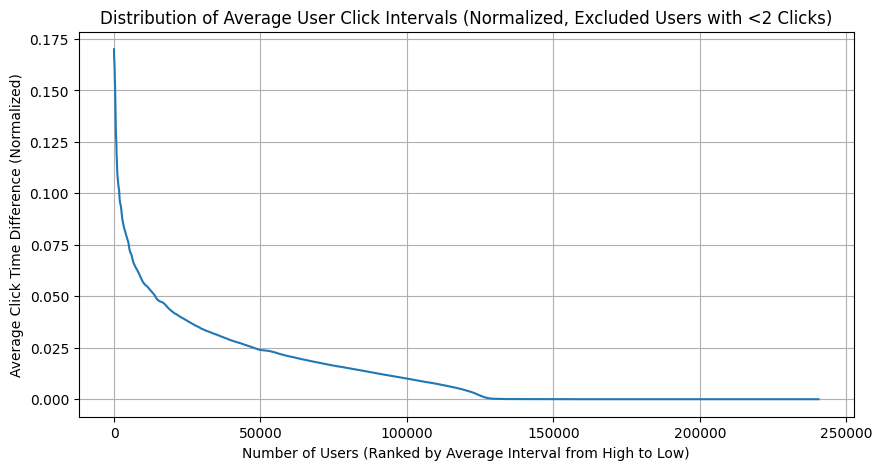

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sorted(mean_diff_click_time_filtered.values, reverse=True))
plt.title("Distribution of Average User Click Intervals (Normalized, Excluded Users with <2 Clicks)")
plt.xlabel("Number of Users (Ranked by Average Interval from High to Low)")
plt.ylabel("Average Click Time Difference (Normalized)")
plt.grid(True)
plt.show()


“在特征工程阶段，我通过计算用户点击行为的平均时间间隔（Inter-arrival Time），来刻画用户的阅读节奏。

1.识别用户粘性：时间间隔非常短的用户，通常处于**‘沉浸式阅读’状态，他们对内容的连贯性要求很高；而间隔非常长的用户，可能是‘碎片化阅读’**。

2.反作弊/过滤噪音：如果一个用户的平均间隔只有几秒钟，那他极大概率不是人在阅读，而是爬虫机器人。

3， 特征输入：我会将这个‘平均点击间隔’作为一个数值特征喂给 YouTube DNN。这能帮助模型分辨：当前用户是那种‘急着看下一篇’的快节奏读者，还是‘细嚼慢咽’的深度读者，从而匹配不同长度和深度的内容。”

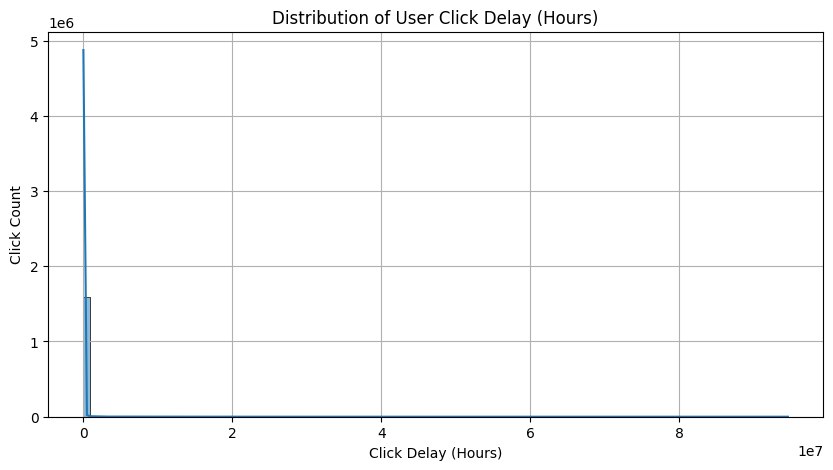

In [69]:
# 1. 确保时间戳字段为数值型（防止是字符串）
user_click_merge['click_timestamp'] = pd.to_numeric(user_click_merge['click_timestamp'], errors='coerce')
user_click_merge['created_at_ts'] = pd.to_numeric(user_click_merge['created_at_ts'], errors='coerce')

# 2. 计算点击延迟（以秒为单位）
user_click_merge['click_article_delay'] = user_click_merge['click_timestamp'] - user_click_merge['created_at_ts']

# 3. 剔除异常值（点击时间早于发布时间的情况）
user_click_merge = user_click_merge[user_click_merge['click_article_delay'] >= 0].copy()

# 4. 归一化点击延迟（MinMax 到 [0, 1]）
scaler = MinMaxScaler()
user_click_merge['click_article_delay_norm'] = scaler.fit_transform(user_click_merge[['click_article_delay']])

# 5. 每个用户的平均点击延迟（单位：秒）
user_avg_delay = user_click_merge.groupby('user_id')['click_article_delay'].mean().reset_index()
user_avg_delay.columns = ['user_id', 'avg_click_delay']

# 6. 每个用户的平均点击延迟（归一化）
user_avg_delay_norm = user_click_merge.groupby('user_id')['click_article_delay_norm'].mean().reset_index()
user_avg_delay_norm.columns = ['user_id', 'avg_click_delay_norm']

# 7. 可选：合并两列一起看
user_avg_delay_all = pd.merge(user_avg_delay, user_avg_delay_norm, on='user_id')

# 8. 可视化（点击延迟分布，单位：小时）
plt.figure(figsize=(10, 5))
sns.histplot(user_click_merge['click_article_delay'] / 3600, bins=100, kde=True)
plt.title("Distribution of User Click Delay (Hours)")
plt.xlabel("Click Delay (Hours)")
plt.ylabel("Click Count")
plt.grid(True)
plt.show()


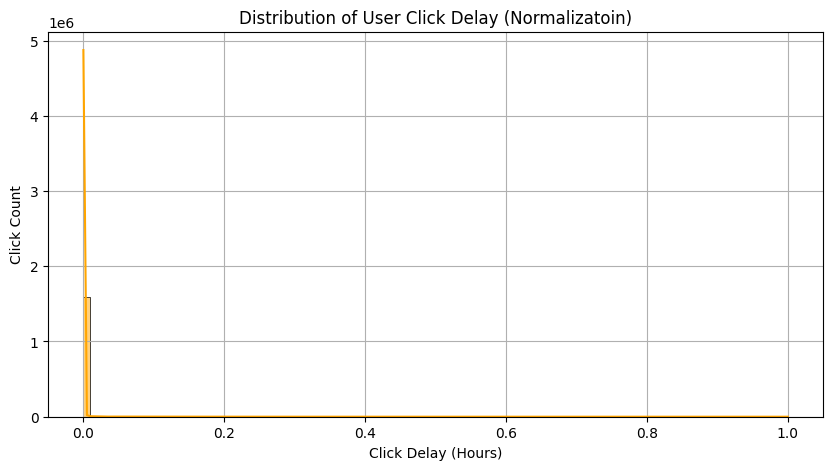

In [70]:
# 9. 可视化（归一化延迟分布）
plt.figure(figsize=(10, 5))
sns.histplot(user_click_merge['click_article_delay_norm'], bins=100, kde=True, color='orange')
plt.title("Distribution of User Click Delay (Normalizatoin)")
plt.xlabel("Click Delay (Hours)")
plt.ylabel("Click Count")
plt.grid(True)
plt.show()

“为了消除不同特征之间的量纲影响（Scale difference）。新闻点击延迟和用户历史长度在数值量级上差异巨大，归一化可以防止大数特征主导损失函数，并能显著加快模型的收敛速度，避免训练过程中的梯度饱和问题。”

In [71]:
# 查看前几行样本（包括原始时间戳和计算出来的延迟）
sample_df = user_click_merge[['user_id', 'click_timestamp', 'created_at_ts', 'click_article_delay', 'click_article_delay_norm']].head(10)
print(sample_df)

   user_id  click_timestamp  created_at_ts  click_article_delay  \
0   199999    1507029570190  1506942089000             87481190   
1   199999    1507029571478  1506994257000             35314478   
2   199999    1507029601478  1507013614000             15987478   
3   199998    1507029532200  1506983935000             45597200   
4   199998    1507029671831  1506938444000             91227831   
5   199998    1507029804858  1506695631000            334173858   
6   199998    1507029834858  1506663059000            366775858   
7   199997    1507029683061  1507013963000             15720061   
8   199997    1507029713061  1506794753000            234960061   
9   199996    1507029600494  1506984684000             44916494   

   click_article_delay_norm  
0                  0.000257  
1                  0.000104  
2                  0.000047  
3                  0.000134  
4                  0.000268  
5                  0.000981  
6                  0.001077  
7                  0.0

In [72]:
print("click_timestamp 范围：", user_click_merge['click_timestamp'].min(), user_click_merge['click_timestamp'].max())
print("created_at_ts 范围：", user_click_merge['created_at_ts'].min(), user_click_merge['created_at_ts'].max())


click_timestamp 范围： 1506959050386 1510603424886
created_at_ts 范围： 1166572800000 1510577019000


In [73]:
# 1. 先做基础统计（毫秒为单位）
delay_stats = user_click_merge['click_article_delay'].describe()
print("📊 原始延迟统计（单位：毫秒）")
print(delay_stats)

# 2. 将关键统计值转换为小时、分钟、秒格式
def ms_to_hms(ms):
    seconds = ms / 1000
    minutes = seconds / 60
    hours = minutes / 60
    return {
        '秒': round(seconds, 2),
        '分钟': round(minutes, 2),
        '小时': round(hours, 2)
    }

print("\n⏱️ 各个统计量对应的可读时间：")
for name in ['min', '25%', '50%', 'mean', '75%', 'max']:
    val = delay_stats[name]
    readable = ms_to_hms(val)
    print(f"{name}：{val:.0f} 毫秒 ≈ {readable['小时']} 小时 / {readable['分钟']} 分钟 / {readable['秒']} 秒")


📊 原始延迟统计（单位：毫秒）
count    1.628883e+06
mean     8.363060e+08
std      7.633853e+09
min      4.572000e+03
25%      1.915627e+07
50%      2.901482e+07
75%      5.700520e+07
max      3.404834e+11
Name: click_article_delay, dtype: float64

⏱️ 各个统计量对应的可读时间：
min：4572 毫秒 ≈ 0.0 小时 / 0.08 分钟 / 4.57 秒
25%：19156272 毫秒 ≈ 5.32 小时 / 319.27 分钟 / 19156.27 秒
50%：29014825 毫秒 ≈ 8.06 小时 / 483.58 分钟 / 29014.82 秒
mean：836306003 毫秒 ≈ 232.31 小时 / 13938.43 分钟 / 836306.0 秒
75%：57005202 毫秒 ≈ 15.83 小时 / 950.09 分钟 / 57005.2 秒
max：340483447542 毫秒 ≈ 94578.74 小时 / 5674724.13 分钟 / 340483447.54 秒


In [74]:
# 四分位以上的更多分位点
quantile_points = [0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 1.0]

# 计算点击延迟分位值（毫秒）
delay_quantiles_ms = user_click_merge['click_article_delay'].quantile(quantile_points)

# 转换为小时 + 打印
print("📊 点击延迟分布关键分位点（单位：小时）\n")
for q in quantile_points:
    ms = delay_quantiles_ms[q]
    hours = ms / (1000 * 60 * 60)
    print(f"{int(q*100):>2d}% 分位点：{ms:.0f} ms ≈ {hours:.2f} 小时")


📊 点击延迟分布关键分位点（单位：小时）

75% 分位点：57005202 ms ≈ 15.83 小时
80% 分位点：68362453 ms ≈ 18.99 小时
85% 分位点：82214595 ms ≈ 22.84 小时
90% 分位点：95544932 ms ≈ 26.54 小时
95% 分位点：166337735 ms ≈ 46.20 小时
99% 分位点：23426456105 ms ≈ 6507.35 小时
100% 分位点：340483447542 ms ≈ 94578.74 小时


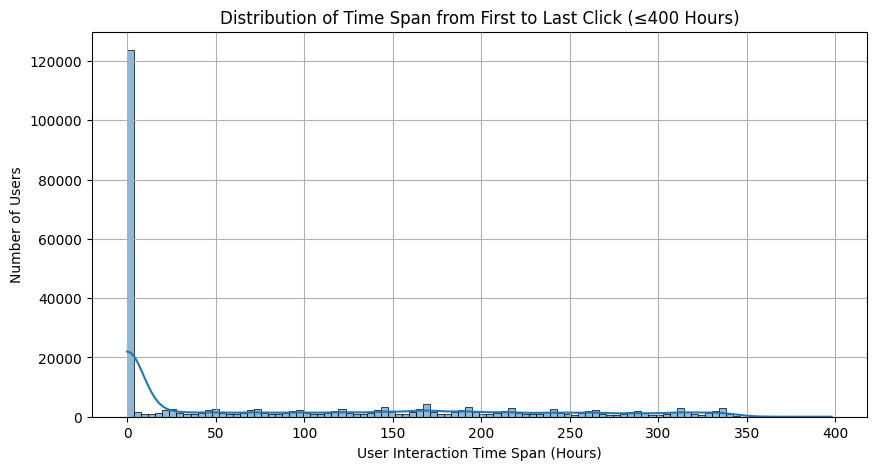

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 统计每个用户的点击时间跨度（单位：毫秒）
user_click_span_ms = user_click_merge.groupby('user_id')['click_timestamp'].agg(['min', 'max'])
user_click_span_ms['click_span_ms'] = user_click_span_ms['max'] - user_click_span_ms['min']

# 2. 转换为小时
user_click_span_ms['click_span_hours'] = user_click_span_ms['click_span_ms'] / (1000 * 60 * 60)

# ✅ 3. 筛选：只保留 400 小时以内的用户
filtered_span = user_click_span_ms[user_click_span_ms['click_span_hours'] <= 400]['click_span_hours']

# 4. 画出分布图（限制在 400 小时以内）
plt.figure(figsize=(10, 5))
sns.histplot(filtered_span, bins=100, kde=True)
plt.xlabel("User Interaction Time Span (Hours)")
plt.ylabel("Number of Users")
plt.title("Distribution of Time Span from First to Last Click (≤400 Hours)")
plt.grid(True)
plt.show()


In [76]:
# 获取所有用户从第一次到最后一次点击的时间跨度（单位：小时）
click_span_hours = user_click_span_ms['click_span_hours']

# 输出描述性统计信息
print("📊 用户点击时间跨度统计（单位：小时）\n")
print(click_span_hours.describe())

# 可选：转换为更人类友好的格式
def hours_to_dhms(hours):
    seconds = int(hours * 3600)
    days = seconds // (3600 * 24)
    hours = (seconds % (3600 * 24)) // 3600
    minutes = (seconds % 3600) // 60
    return f"{days}天 {hours}小时 {minutes}分钟"

# 举例：输出最大值、平均值对应的可读时间
max_val = click_span_hours.max()
mean_val = click_span_hours.mean()
median_val = click_span_hours.median()

print(f"\n🕒 最大点击跨度：{max_val:.2f} 小时 ≈ {hours_to_dhms(max_val)}")
print(f"🕒 平均点击跨度：{mean_val:.2f} 小时 ≈ {hours_to_dhms(mean_val)}")
print(f"🕒 中位数点击跨度：{median_val:.2f} 小时 ≈ {hours_to_dhms(median_val)}")


📊 用户点击时间跨度统计（单位：小时）

count    200000.000000
mean         66.675150
std          94.450595
min           0.000000
25%           0.008333
50%           0.122825
75%         130.497296
max         695.838119
Name: click_span_hours, dtype: float64

🕒 最大点击跨度：695.84 小时 ≈ 28天 23小时 50分钟
🕒 平均点击跨度：66.68 小时 ≈ 2天 18小时 40分钟
🕒 中位数点击跨度：0.12 小时 ≈ 0天 0小时 7分钟


In [84]:
# 分位点设置：你想看的高位段
quantile_points = [0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 1.0]

# 计算分位值
span_quantiles = click_span_hours.quantile(quantile_points)

# 打印结果（含可读时间格式）
print("📊 用户点击时间跨度的高分位分布（单位：小时 + 人类时间）\n")
def hours_to_dhms(hours):
    seconds = int(hours * 3600)
    days = seconds // (3600 * 24)
    hours = (seconds % (3600 * 24)) // 3600
    minutes = (seconds % 3600) // 60
    return f"{days}天 {hours}小时 {minutes}分钟"

for q in quantile_points:
    h = span_quantiles[q]
    readable = hours_to_dhms(h)
    print(f"{int(q*100):>2d}% 分位点：{h:.2f} 小时 ≈ {readable}")


📊 用户点击时间跨度的高分位分布（单位：小时 + 人类时间）

75% 分位点：130.50 小时 ≈ 5天 10小时 29分钟
80% 分位点：161.13 小时 ≈ 6天 17小时 8分钟
85% 分位点：187.89 小时 ≈ 7天 19小时 53分钟
90% 分位点：226.74 小时 ≈ 9天 10小时 44分钟
95% 分位点：271.98 小时 ≈ 11天 7小时 58分钟
99% 分位点：312.20 小时 ≈ 13天 0小时 11分钟
100% 分位点：695.84 小时 ≈ 28天 23小时 50分钟
